# 3 — Fashion-MNIST: classificar peças de roupa com uma CNN

**Objetivo.** Reutilizar uma CNN pequena em um problema visual mais ambíguo que dígitos. Usaremos 12.000 imagens para treino, 2.000 para validação, as 10.000 imagens oficiais de teste e 3 épocas.

O fluxo segue o tutorial oficial [Classificação básica: roupas](https://www.tensorflow.org/tutorials/keras/classification), com um recorte menor e uma CNN explícita para execução didática rápida.

## 1. Dados, classes e partições

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

print("TensorFlow", tf.__version__)

I0000 00:00:1789564563.360928 1666173 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564563.361189 1666173 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0


I0000 00:00:1789564563.984318 1666173 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564563.984461 1666173 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
nomes_classes = [
    "camiseta/top", "calça", "suéter", "vestido", "casaco",
    "sandália", "camisa", "tênis", "bolsa", "bota",
]
(x_dev, y_dev), (x_teste, y_teste) = tf.keras.datasets.fashion_mnist.load_data()

rng = np.random.default_rng(42)
indices = rng.permutation(len(x_dev))
indices_treino = indices[:12_000]
indices_validacao = indices[12_000:14_000]

x_treino = x_dev[indices_treino].astype("float32") / 255.0
y_treino = y_dev[indices_treino]
x_validacao = x_dev[indices_validacao].astype("float32") / 255.0
y_validacao = y_dev[indices_validacao]
x_teste = x_teste.astype("float32") / 255.0

x_treino = x_treino[..., np.newaxis]
x_validacao = x_validacao[..., np.newaxis]
x_teste = x_teste[..., np.newaxis]

assert set(indices_treino).isdisjoint(indices_validacao)
print(f"treino: {len(x_treino)} · validação: {len(x_validacao)} · teste: {len(x_teste)}")

treino: 12000 · validação: 2000 · teste: 10000


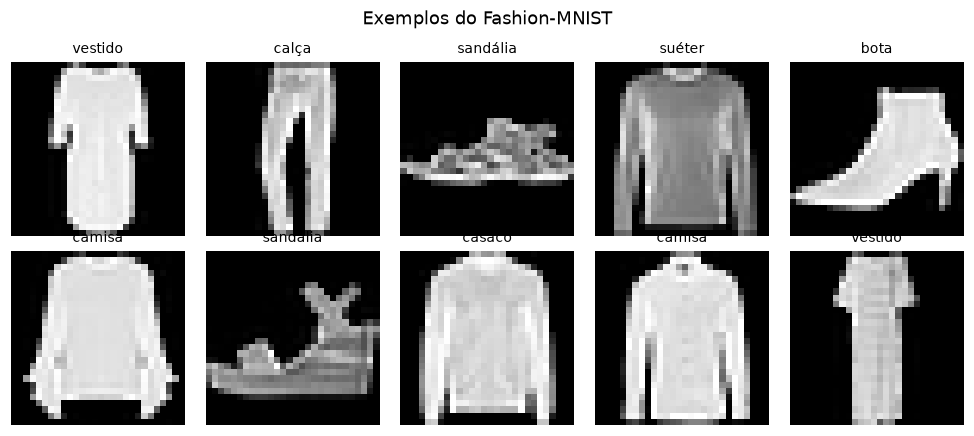

In [3]:
fig, eixos = plt.subplots(2, 5, figsize=(9, 4))
for eixo, imagem, rotulo in zip(eixos.flat, x_treino[:10], y_treino[:10]):
    eixo.imshow(imagem[:, :, 0], cmap="gray")
    eixo.set_title(nomes_classes[rotulo], fontsize=9)
    eixo.axis("off")
fig.suptitle("Exemplos do Fashion-MNIST")
plt.tight_layout()

## 2. CNN pequena

A saída possui dez neurônios com `softmax`, um por classe. Assim como no MNIST, a perda compara a distribuição prevista com o rótulo correto. O modelo é pequeno e treinado do zero; não usamos transferência de aprendizado nem callbacks avançados.

In [4]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="cnn_fashion_mnist")
modelo.summary()

E0000 00:00:1789564564.590532 1666173 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "cnn_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,762 (120.16 KB)

 Trainable params: 30,762 (120.16 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [6]:
historia = modelo.fit(
    x_treino,
    y_treino,
    validation_data=(x_validacao, y_validacao),
    epochs=3,
    batch_size=128,
    verbose=2,
)

Epoch 1/3


94/94 - 1s - 10ms/step - accuracy: 0.5681 - loss: 1.2232 - val_accuracy: 0.7380 - val_loss: 0.7420


Epoch 2/3


94/94 - 0s - 5ms/step - accuracy: 0.7708 - loss: 0.6304 - val_accuracy: 0.7620 - val_loss: 0.6450


Epoch 3/3


94/94 - 0s - 5ms/step - accuracy: 0.7971 - loss: 0.5508 - val_accuracy: 0.7880 - val_loss: 0.5695


## 3. Curvas de aprendizagem e teste

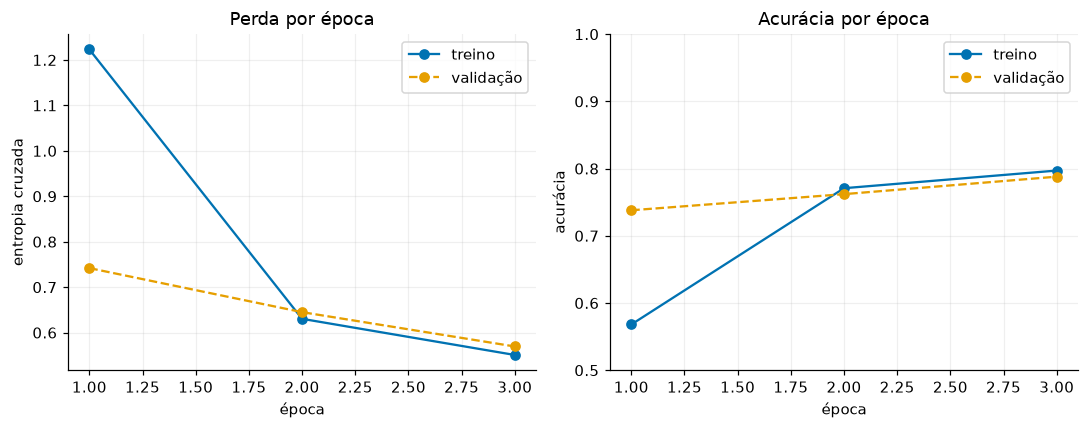

In [7]:
epocas = range(1, 4)
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
eixos[0].plot(epocas, historia.history["loss"], "o-", color="#0072B2", label="treino")
eixos[0].plot(epocas, historia.history["val_loss"], "o--", color="#E69F00", label="validação")
eixos[1].plot(epocas, historia.history["accuracy"], "o-", color="#0072B2", label="treino")
eixos[1].plot(epocas, historia.history["val_accuracy"], "o--", color="#E69F00", label="validação")
eixos[0].set(title="Perda por época", xlabel="época", ylabel="entropia cruzada")
eixos[1].set(title="Acurácia por época", xlabel="época", ylabel="acurácia", ylim=(0.5, 1.0))
for eixo in eixos:
    eixo.legend()
plt.tight_layout()

In [8]:
perda_teste, acc_teste = modelo.evaluate(x_teste, y_teste, verbose=0)
print(f"Teste final — perda: {perda_teste:.4f}; acurácia: {acc_teste:.4f}")
print("O teste foi usado somente agora, depois de finalizar o treino.")

Teste final — perda: 0.5622; acurácia: 0.7931
O teste foi usado somente agora, depois de finalizar o treino.


## 4. Erros e confusões

Algumas classes têm formato parecido em 28×28 pixels: “camiseta/top”, “camisa”, “suéter” e “casaco” podem compartilhar contornos. A matriz de confusão conta a classe real nas linhas e a prevista nas colunas.

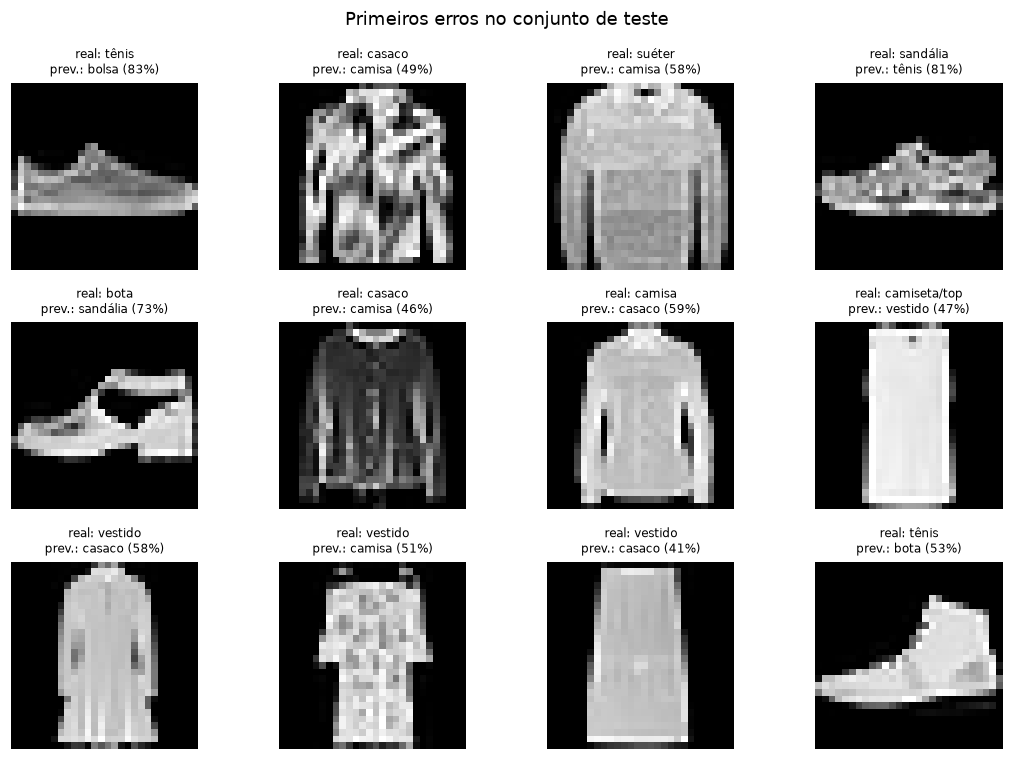

In [9]:
probabilidades = modelo.predict(x_teste, verbose=0)
previstos = probabilidades.argmax(axis=1)
erros = np.flatnonzero(previstos != y_teste)[:12]

fig, eixos = plt.subplots(3, 4, figsize=(10, 7))
for eixo, indice in zip(eixos.flat, erros):
    eixo.imshow(x_teste[indice, :, :, 0], cmap="gray")
    eixo.set_title(
        f"real: {nomes_classes[y_teste[indice]]}\n"
        f"prev.: {nomes_classes[previstos[indice]]} ({probabilidades[indice, previstos[indice]]:.0%})",
        fontsize=8,
    )
    eixo.axis("off")
fig.suptitle("Primeiros erros no conjunto de teste")
plt.tight_layout()

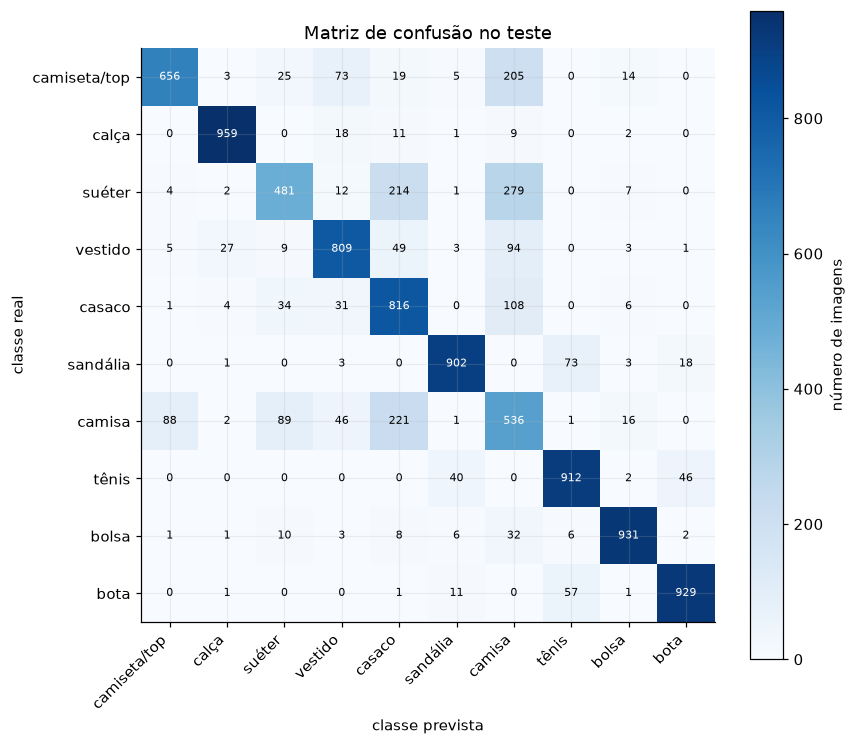

In [10]:
matriz = np.zeros((10, 10), dtype=int)
np.add.at(matriz, (y_teste, previstos), 1)

fig, eixo = plt.subplots(figsize=(8, 7))
imagem = eixo.imshow(matriz, cmap="Blues")
eixo.set(
    title="Matriz de confusão no teste",
    xlabel="classe prevista",
    ylabel="classe real",
    xticks=range(10),
    yticks=range(10),
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
)
plt.setp(eixo.get_xticklabels(), rotation=45, ha="right")
for linha in range(10):
    for coluna in range(10):
        cor = "white" if matriz[linha, coluna] > matriz.max() / 2 else "black"
        eixo.text(coluna, linha, matriz[linha, coluna], ha="center", va="center", color=cor, fontsize=7)
fig.colorbar(imagem, ax=eixo, label="número de imagens")
plt.tight_layout()

## Síntese

- Treino, validação e teste são conjuntos separados; isso evita escolher o modelo olhando o resultado final.
- A CNN aprende padrões locais, mas 3 épocas e 12.000 imagens impõem um limite deliberado.
- A matriz de confusão revela quais categorias concentram os erros; acurácia sozinha esconde essa estrutura.
- O resultado não demonstra que a arquitetura “entende roupas”: ela aprende regularidades do conjunto Fashion-MNIST.

**Experiência sugerida:** escolha uma dupla frequentemente confundida, filtre apenas essas imagens e compare visualmente bordas e silhuetas.